成功讀入資料筆數： 251
   year  count    scenario    model     ssp
0  2004     10  historical  TaiESM1  ssp245
1  2005     14  historical  TaiESM1  ssp245
2  2006      7  historical  TaiESM1  ssp245
3  2007      7  historical  TaiESM1  ssp245
4  2008      5  historical  TaiESM1  ssp245


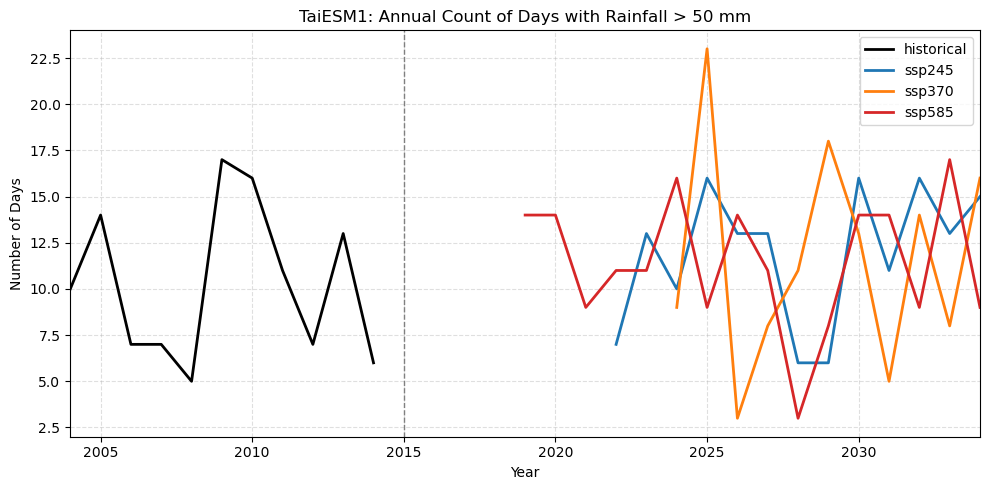

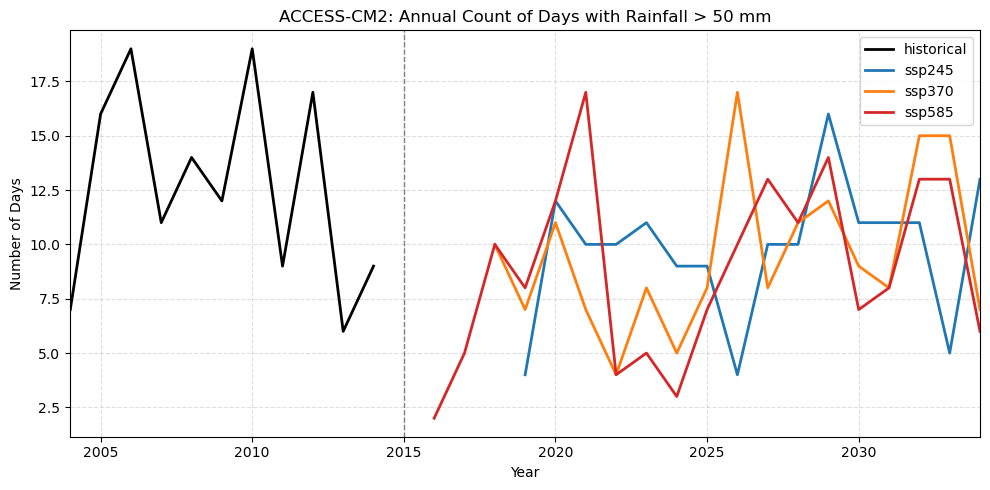

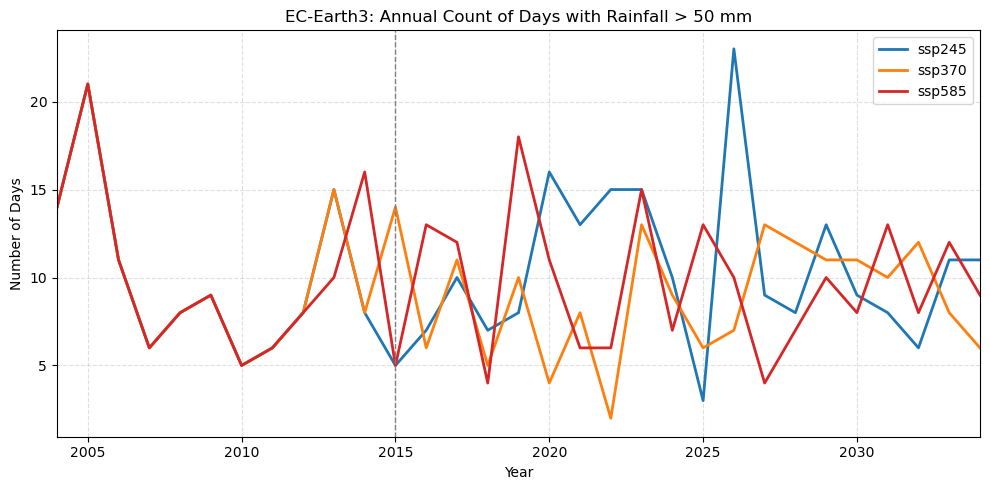

ssp       model  year  ssp245  ssp370  ssp585
0    ACCESS-CM2  2004     7.0     7.0     7.0
1    ACCESS-CM2  2005    16.0    16.0    16.0
2    ACCESS-CM2  2006    19.0    19.0    19.0
3    ACCESS-CM2  2007    11.0    11.0    11.0
4    ACCESS-CM2  2008    14.0    14.0    14.0
5    ACCESS-CM2  2009    12.0    12.0    12.0
6    ACCESS-CM2  2010    19.0    19.0    19.0
7    ACCESS-CM2  2011     9.0     9.0     9.0
8    ACCESS-CM2  2012    17.0    17.0    17.0
9    ACCESS-CM2  2013     6.0     6.0     6.0
10   ACCESS-CM2  2014     9.0     9.0     9.0
11   ACCESS-CM2  2016     NaN     NaN     2.0
12   ACCESS-CM2  2017     NaN     NaN     5.0
13   ACCESS-CM2  2018     NaN    10.0    10.0
14   ACCESS-CM2  2019     4.0     7.0     8.0
15   ACCESS-CM2  2020    12.0    11.0    12.0
16   ACCESS-CM2  2021    10.0     7.0    17.0
17   ACCESS-CM2  2022    10.0     4.0     4.0
18   ACCESS-CM2  2023    11.0     8.0     5.0
19   ACCESS-CM2  2024     9.0     5.0     3.0


In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 基本設定
# =========================
gwl_dir = r"C:\AR6_統計降尺度_日資料_臺北市_降雨量\GWL1.5"
historical_dir = r"C:\AR6_統計降尺度_日資料_臺北市_降雨量\historical"

# 指定格點（大學里）
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# 要分析的模式與情境
models = [
    "TaiESM1",
    "ACCESS-CM2",
    "EC-Earth3"
]

ssps = ["ssp245", "ssp370", "ssp585"]

# 降雨門檻（mm/day）
rain_threshold = 50.0

# 繪圖年份範圍（可自行修改）
start_year = 2004
end_year   = 2034

# 是否顯示歷史 / 未來分界線
split_year = 2015   # historical 到 2014，未來情境通常從 2015 開始


# =========================
# 2. 工具函式
# =========================
def extract_year_from_filename(filepath):
    """
    從檔名抓年份，預期最後會有 _YYYY.csv
    """
    fname = os.path.basename(filepath)
    m = re.search(r'_(\d{4})\.csv$', fname)
    if m:
        return int(m.group(1))
    return None


def find_matching_files(base_dir, model_name=None, ssp=None, historical=False):
    """
    搜尋符合條件的 csv 檔
    historical=True 時只抓 historical 檔
    historical=False 時抓指定 ssp + model 的檔
    """
    all_files = glob.glob(os.path.join(base_dir, "*.csv"))

    matched = []
    for f in all_files:
        fname = os.path.basename(f)

        if historical:
            # historical 檔案需包含 model 且 historical
            if model_name in fname and "historical" in fname:
                matched.append(f)
        else:
            # 未來情境檔需包含 model 與 ssp
            if model_name in fname and ssp in fname:
                matched.append(f)

    # 依年份排序
    matched = sorted(matched, key=lambda x: extract_year_from_filename(x) or 0)
    return matched


def find_nearest_grid_row(df, lat_col="LAT", lon_col="LON", target_lat=25.0, target_lon=121.5):
    """
    找距離指定位置最近的那一列
    """
    tmp = df.copy()
    tmp["dist"] = np.sqrt((tmp[lat_col] - target_lat)**2 + (tmp[lon_col] - target_lon)**2)
    idx = tmp["dist"].idxmin()
    return idx


def daily_columns_from_df(df):
    """
    抓出像 20300101 這種日期欄位
    """
    date_cols = []
    for c in df.columns:
        c_str = str(c)
        if re.fullmatch(r"\d{8}", c_str):
            date_cols.append(c)
    return date_cols


def read_one_year_count(filepath, target_lat, target_lon, threshold=50.0):
    """
    讀單一年份檔案，計算該年降雨 > threshold 的天數
    """
    try:
        df = pd.read_csv(filepath, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding="big5")

    # 找經緯度欄名
    lat_candidates = [c for c in df.columns if str(c).upper() == "LAT"]
    lon_candidates = [c for c in df.columns if str(c).upper() == "LON"]

    if not lat_candidates or not lon_candidates:
        raise ValueError(f"找不到 LAT/LON 欄位：{filepath}")

    lat_col = lat_candidates[0]
    lon_col = lon_candidates[0]

    idx = find_nearest_grid_row(df, lat_col=lat_col, lon_col=lon_col,
                                target_lat=target_lat, target_lon=target_lon)
    row = df.loc[idx]

    date_cols = daily_columns_from_df(df)
    if len(date_cols) == 0:
        raise ValueError(f"找不到日期欄位：{filepath}")

    vals = pd.to_numeric(row[date_cols], errors="coerce")
    count_gt50 = (vals > threshold).sum()

    # 年份以檔名為主
    year = extract_year_from_filename(filepath)
    if year is None:
        # 備援：從第一個日期欄位抓年份
        year = int(str(date_cols[0])[:4])

    return year, int(count_gt50)


def build_model_ssp_series(model_name, ssp, historical_dir, gwl_dir,
                           target_lat, target_lon, threshold=50.0):
    """
    建立某個 model + ssp 的完整逐年序列
    historical + future 合併
    """
    hist_files = find_matching_files(historical_dir, model_name=model_name, historical=True)
    fut_files  = find_matching_files(gwl_dir, model_name=model_name, ssp=ssp, historical=False)

    records = []

    # historical
    for f in hist_files:
        year = extract_year_from_filename(f)
        if year is None:
            continue
        try:
            y, cnt = read_one_year_count(f, target_lat, target_lon, threshold=threshold)
            records.append({"year": y, "count": cnt, "scenario": "historical"})
        except Exception as e:
            print(f"[FAIL historical] {model_name} | {os.path.basename(f)} | {e}")

    # future
    for f in fut_files:
        year = extract_year_from_filename(f)
        if year is None:
            continue
        try:
            y, cnt = read_one_year_count(f, target_lat, target_lon, threshold=threshold)
            records.append({"year": y, "count": cnt, "scenario": ssp})
        except Exception as e:
            print(f"[FAIL future] {model_name} | {ssp} | {os.path.basename(f)} | {e}")

    if len(records) == 0:
        return pd.DataFrame(columns=["year", "count", "scenario", "model", "ssp"])

    out = pd.DataFrame(records).drop_duplicates(subset=["year"], keep="last")
    out = out.sort_values("year").reset_index(drop=True)
    out["model"] = model_name
    out["ssp"] = ssp
    return out


# =========================
# 3. 建立所有資料
# =========================
all_data = []

for model in models:
    for ssp in ssps:
        df_series = build_model_ssp_series(
            model_name=model,
            ssp=ssp,
            historical_dir=historical_dir,
            gwl_dir=gwl_dir,
            target_lat=poi_lat,
            target_lon=poi_lon,
            threshold=rain_threshold
        )

        if df_series.empty:
            print(f"[SKIP] {model} | {ssp}: 沒有可用資料")
        else:
            # 限制年份範圍
            df_series = df_series[(df_series["year"] >= start_year) & (df_series["year"] <= end_year)]
            if not df_series.empty:
                all_data.append(df_series)
            else:
                print(f"[SKIP] {model} | {ssp}: 指定年份範圍內沒有資料")

if len(all_data) == 0:
    raise ValueError("沒有任何資料成功讀入，請檢查路徑、檔名或模式名稱。")

all_df = pd.concat(all_data, ignore_index=True)

print("成功讀入資料筆數：", len(all_df))
print(all_df.head())


# =========================
# 4. 畫圖：每個模式一張圖，三個 SSP
# =========================
color_map = {
    "ssp245": "tab:blue",
    "ssp370": "tab:orange",
    "ssp585": "tab:red"
}

for model in models:
    plt.figure(figsize=(10, 5))

    # 先畫 historical（只取一條，避免三個 ssp 重複畫出一模一樣的歷史）
    hist_drawn = False

    for ssp in ssps:
        sub = all_df[(all_df["model"] == model) & (all_df["ssp"] == ssp)].copy()
        if sub.empty:
            continue

        # historical
        hist = sub[sub["scenario"] == "historical"].sort_values("year")
        fut  = sub[sub["scenario"] == ssp].sort_values("year")

        if (not hist.empty) and (not hist_drawn):
            plt.plot(
                hist["year"], hist["count"],
                color="black", linewidth=2, label="historical"
            )
            hist_drawn = True

        # future
        if not fut.empty:
            plt.plot(
                fut["year"], fut["count"],
                color=color_map.get(ssp, None),
                linewidth=2, label=ssp
            )

    plt.axvline(split_year, color="gray", linestyle="--", linewidth=1)

    plt.title(f"{model}: Annual Count of Days with Rainfall > {rain_threshold:.0f} mm")
    plt.xlabel("Year")
    plt.ylabel("Number of Days")
    plt.xlim(start_year, end_year)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 5. 如果你想看整理後表格
# =========================
pivot_df = all_df.pivot_table(
    index=["model", "year"],
    columns="ssp",
    values="count",
    aggfunc="first"
).reset_index()

print(pivot_df.head(20))

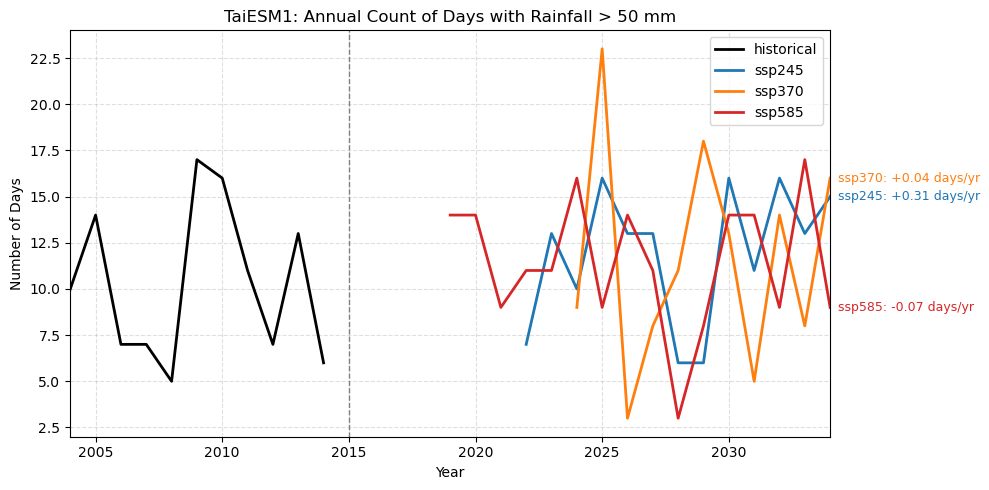

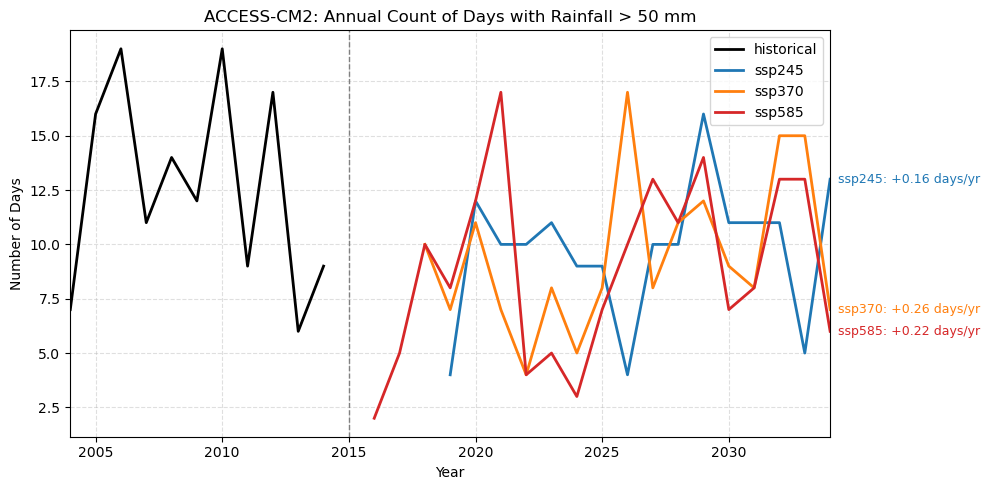

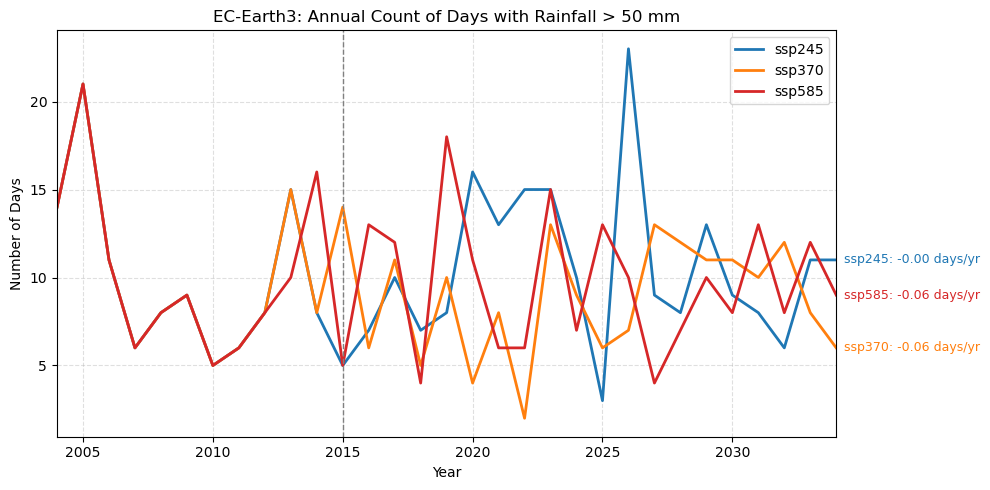

In [2]:
for model in models:
    plt.figure(figsize=(10, 5))

    hist_drawn = False

    for ssp in ssps:
        sub = all_df[(all_df["model"] == model) & (all_df["ssp"] == ssp)].copy()
        if sub.empty:
            continue

        hist = sub[sub["scenario"] == "historical"].sort_values("year")
        fut  = sub[sub["scenario"] == ssp].sort_values("year")

        # ===== historical =====
        if (not hist.empty) and (not hist_drawn):
            plt.plot(
                hist["year"], hist["count"],
                color="black", linewidth=2, label="historical"
            )
            hist_drawn = True

        # ===== future =====
        if not fut.empty:
            plt.plot(
                fut["year"], fut["count"],
                color=color_map.get(ssp, None),
                linewidth=2, label=ssp
            )

            # ===== 計算趨勢（線性回歸）=====
            x = fut["year"].values
            y = fut["count"].values

            if len(x) > 1:
                slope, intercept = np.polyfit(x, y, 1)

                # 顯示文字（放在最後一年位置）
                text_x = x[-1]
                text_y = y[-1]

                plt.text(
                    text_x + 0.3, text_y,
                    f"{ssp}: {slope:+.2f} days/yr",
                    color=color_map.get(ssp, None),
                    fontsize=9,
                    verticalalignment="center"
                )

    # 分界線
    plt.axvline(split_year, color="gray", linestyle="--", linewidth=1)

    plt.title(f"{model}: Annual Count of Days with Rainfall > {rain_threshold:.0f} mm")
    plt.xlabel("Year")
    plt.ylabel("Number of Days")
    plt.xlim(start_year, end_year)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

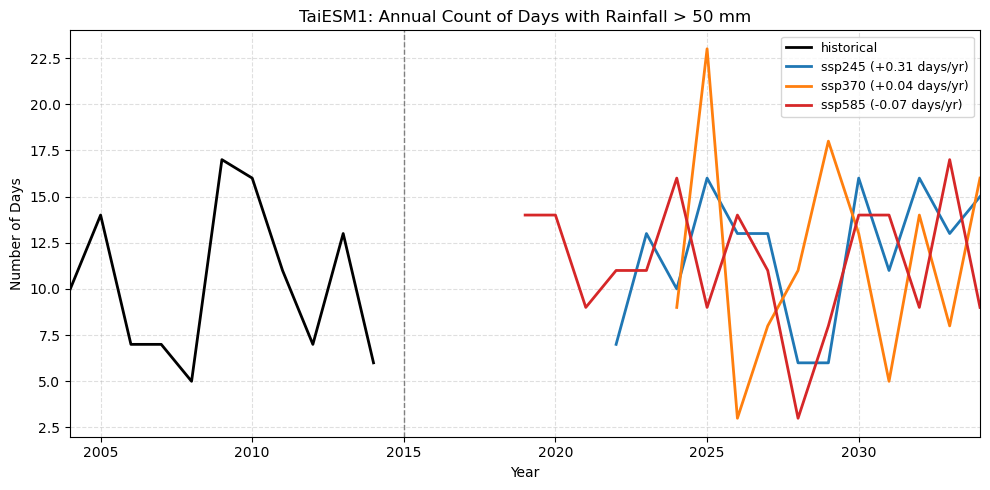

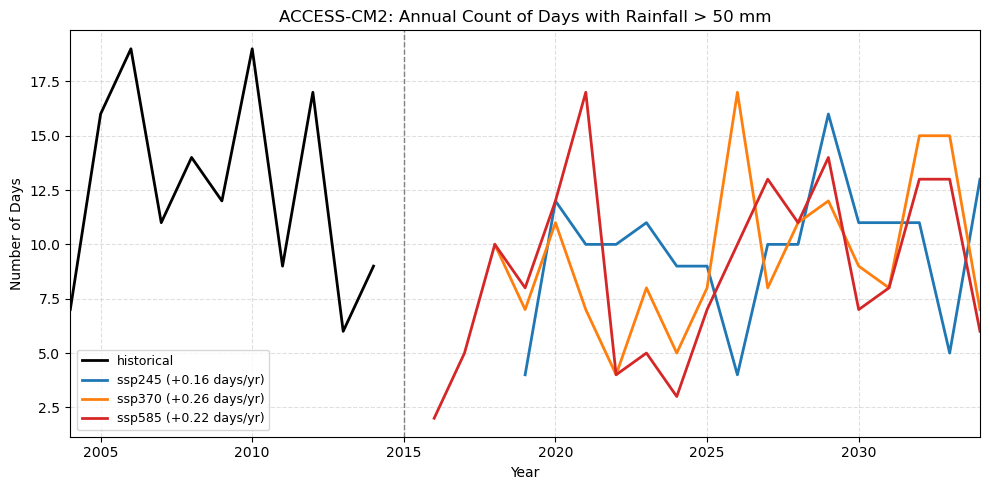

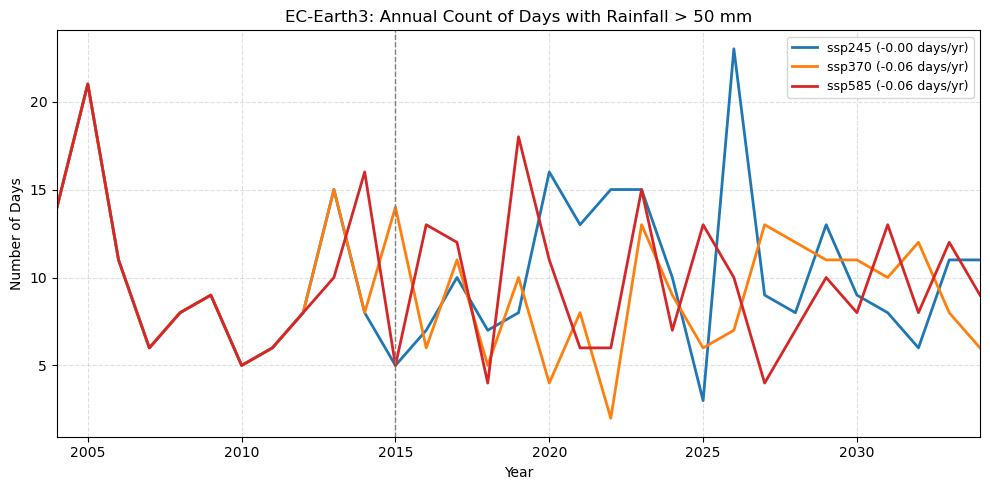

In [8]:
from pathlib import Path
# =========================
# 4. 畫圖：每個模式一張圖
#    趨勢寫進 legend，不畫趨勢線
# =========================
for model in models:
    fig, ax = plt.subplots(figsize=(10, 5))

    hist_drawn = False

    for ssp in ssps:
        sub = all_df[
            (all_df["model"] == model) &
            (all_df["ssp"] == ssp)
        ].copy()

        if sub.empty:
            continue

        hist = sub[sub["scenario"] == "historical"].sort_values("year")
        fut = sub[sub["scenario"] == ssp].sort_values("year")

        # historical 只畫一次
        if (not hist.empty) and (not hist_drawn):
            ax.plot(
                hist["year"],
                hist["count"],
                color="black",
                linewidth=2,
                label="historical"
            )
            hist_drawn = True

        # future
        if not fut.empty:
            x = fut["year"].values
            y = fut["count"].values

            label_text = ssp
            if len(x) > 1:
                slope, _ = np.polyfit(x, y, 1)
                label_text = f"{ssp} ({slope:+.2f} days/yr)"

            ax.plot(
                x,
                y,
                color=color_map.get(ssp, None),
                linewidth=2,
                label=label_text
            )

    ax.axvline(split_year, color="gray", linestyle="--", linewidth=1)

    ax.set_title(f"{model}: Annual Count of Days with Rainfall > {rain_threshold:.0f} mm")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Days")
    ax.set_xlim(start_year, end_year)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best", fontsize=9)

    save_dir = Path(r"\Users\user\Climate_project\程式作業\Daxue＿village\figue")
    out_path = save_dir /f"{model} Annual Count of Days with Rainfall over {rain_threshold:.0f} mm.png"
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

